In [614]:
import pandas as pd
import numpy as np

In [615]:
df=pd.read_csv('student_dataset_dirty.csv')

## Data clean 

In [616]:
df.shape

(10000, 15)

In [617]:
df.columns

Index(['Student_ID', 'Name', 'Age', 'Gender', 'City', 'Class',
       'Attendance_Percentage', 'Study_Hours_per_day', 'Math_Score',
       'Science_Score', 'English_Score', 'Total_Score', 'Parent_Education',
       'Internet_Access', 'Result'],
      dtype='object')

In [618]:
df.isnull().mean()

Student_ID               0.0000
Name                     0.0042
Age                      0.0196
Gender                   0.0838
City                     0.0225
Class                    0.0000
Attendance_Percentage    0.0255
Study_Hours_per_day      0.0197
Math_Score               0.0195
Science_Score            0.0200
English_Score            0.0196
Total_Score              0.0316
Parent_Education         0.1100
Internet_Access          0.1646
Result                   0.1094
dtype: float64

In [619]:
cols_to_drop = df.columns[df.isnull().mean() > 0.5].tolist()
df.drop(columns=cols_to_drop, inplace=True)

## Fix Data Types

In [620]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  object 
 1   Name                   9958 non-null   object 
 2   Age                    9804 non-null   object 
 3   Gender                 9162 non-null   object 
 4   City                   9775 non-null   object 
 5   Class                  10000 non-null  object 
 6   Attendance_Percentage  9745 non-null   float64
 7   Study_Hours_per_day    9803 non-null   float64
 8   Math_Score             9805 non-null   object 
 9   Science_Score          9800 non-null   object 
 10  English_Score          9804 non-null   object 
 11  Total_Score            9684 non-null   object 
 12  Parent_Education       8900 non-null   object 
 13  Internet_Access        8354 non-null   object 
 14  Result                 8906 non-null   object 
dtypes: 

In [621]:
df['Age']=df['Age'].str.strip()
df['Age']=pd.to_numeric(df['Age'],errors='coerce')

In [622]:
df['Age'].dtype

dtype('float64')

In [623]:
df['Age'].unique()

array([ 16.,  12.,  14.,  11.,  18.,  17.,  15., 227.,  13.,  nan,  -9.,
        -8., -13.,  -1., 290., 252., -15., 291., 150., 180., 152., 283.,
        -4., 231., 235., 170., 182., -11., 269., 292.,  -2., 248., 219.,
       -14., 238.,  -6., 171., -10., 233., 245., 209.,  -5., 218., 164.,
       296., 221., 173., -12., 194., 169., 295., -19., 268., 174., 176.,
       223., 160., 214., 253., 243., 229.,  -3., 211., 179., 203., 181.,
       159., 198., -17., 288., 287., 297., 228., 154., 220., -18., 156.,
       196., 188., 281., 206., 264., 216., 165., 240., 187., 298., 197.,
       255., 271., 195., 190., 239.,  -7., 260., 192.])

In [624]:
df.loc[(df["Age"] < 6) | (df["Age"] > 18), "Age"] = np.nan

In [625]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [626]:
df['Math_Score'].unique()

array(['83', '45', '37', '81', '47', '36', '76', nan, '69', '32', '67',
       '93', '97', '98', '90', '48', '60', '78', '65', '72', '92', '40',
       '46', '43', '51', '130', '62', '33', '53', '66', '61', 'absent',
       '91', '50', '42', '79', '57', '49', '52', '30', '74', '75', '55',
       '99', '88', '70', '35', '34', '80', '95', '89', '54', '56', '31',
       '84', '71', '86', '87', '77', '68', '38', '82', '44', '73', '58',
       '59', '39', '41', '96', '63', '64', '85', '94', '-20', '-17',
       '-48', '-39', '251', '233', '289', '228', '-44', '186', '-15',
       '257', '243', '-32', '-31', '-19', '260', '-29', '232', '213',
       '262', '-16', '175', '126', '184', '-21', '-13', '-14', '261',
       '297', '-37', '-41', '204', '239', '-45', '161', '-26', '-22',
       '292', '268', '-34', '290', '191', '-11', '190', '200', '282',
       '115', '-24', '286', '159', '119', '139', '255', '101', '148',
       '147', '-12', '-18', '216', '-23', '198', '234', '-7', '157',
      

In [627]:
df['Math_Score']=pd.to_numeric(df['Math_Score'],errors='coerce')

In [628]:
df.loc[df['Math_Score']<=0,'Math_Score']=0

In [629]:
df.loc[df['Math_Score']>=100,'Math_Score']=100

In [630]:
df['Science_Score'].unique()

array(['62', '56', '82', '96', '36', '48', '51', '80', '75', '92', '37',
       '45', '61', '78', '93', nan, '44', '229', '63', '-12', '54', '71',
       '84', '67', '31', '53', '99', '57', '64', '60', '65', '90', '79',
       '74', '42', '30', '52', '72', '76', '95', '97', '50', '41', '89',
       '55', '86', '70', '87', '47', '81', '98', '68', '43', '88', '85',
       '32', '39', '83', '77', '59', '-48', '34', '58', '91', '35', '38',
       '94', '66', '33', '69', '46', '-15', '49', 'absent', '238', '40',
       '73', '-27', '210', '299', '204', '169', '-10', '-6', '142', '112',
       '174', '134', '195', '-11', '-36', '129', '-46', '-14', '-45',
       '186', '269', '-32', '-13', '121', '-30', '-5', '107', '109',
       '146', '143', '265', '-20', '-8', '296', '-19', '281', '-47',
       '181', '-31', '-44', '-23', '252', '-43', '266', '158', '-24',
       '145', '271', '-17', '-42', '113', '-18', '-29', '122', '177',
       '-34', '-21', '280', '-40', '-49', '260', '-4', '282', '-

In [631]:

df['Science_Score']=pd.to_numeric(df['Science_Score'],errors="coerce")

In [632]:
df.loc[df['Science_Score']<=0,'Science_Score']=0

In [633]:

df.loc[df['Science_Score']>=100,'Science_Score']=100

In [634]:

df['English_Score']=pd.to_numeric(df['English_Score'],errors="coerce")

In [635]:
df.loc[df['English_Score']<=0,'English_Score']=0

In [636]:
df.loc[df['English_Score']>100,'English_Score']=100

In [637]:
df['Total_Score']=pd.to_numeric(df['Total_Score'],errors="coerce")

In [638]:
df.loc[df['Total_Score']<=0,'Total_Score']=0

In [639]:
df.loc[df['Total_Score']>300,'Total_Score']=300

In [640]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  object 
 1   Name                   9958 non-null   object 
 2   Age                    10000 non-null  float64
 3   Gender                 9162 non-null   object 
 4   City                   9775 non-null   object 
 5   Class                  10000 non-null  object 
 6   Attendance_Percentage  9745 non-null   float64
 7   Study_Hours_per_day    9803 non-null   float64
 8   Math_Score             9755 non-null   float64
 9   Science_Score          9763 non-null   float64
 10  English_Score          9763 non-null   float64
 11  Total_Score            9599 non-null   float64
 12  Parent_Education       8900 non-null   object 
 13  Internet_Access        8354 non-null   object 
 14  Result                 8906 non-null   object 
dtypes: 

## Missing Values

In [641]:
df.isnull().sum()

Student_ID                  0
Name                       42
Age                         0
Gender                    838
City                      225
Class                       0
Attendance_Percentage     255
Study_Hours_per_day       197
Math_Score                245
Science_Score             237
English_Score             237
Total_Score               401
Parent_Education         1100
Internet_Access          1646
Result                   1094
dtype: int64

In [642]:
# find numerical columns
num_cols=[]
for col in df.columns:
    if df[col].dtype==float:
        num_cols.append(col)
    

num_cols

['Age',
 'Attendance_Percentage',
 'Study_Hours_per_day',
 'Math_Score',
 'Science_Score',
 'English_Score',
 'Total_Score']

In [643]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [644]:
cat_cols=[]
for col in df.columns:
    if df[col].dtype==object:
        cat_cols.append(col)

cat_cols

['Student_ID',
 'Name',
 'Gender',
 'City',
 'Class',
 'Parent_Education',
 'Internet_Access',
 'Result']

In [645]:
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [646]:
df.shape

(10000, 15)

In [647]:
df = df.drop_duplicates(subset=["Student_ID"], keep="first")

In [648]:
df.shape

(9850, 15)

## Standardize labels

In [649]:

df['Gender'].unique()

array(['MALE', 'F', 'Male', 'FEMALE', 'other', 'M', 'female', 'Female',
       'male', 'Other', 'O'], dtype=object)

In [650]:
df['Gender']=df['Gender'].str.lower().map({
    "male":"M",
   
    'female':"F",
    
    
    'other':'O'

}).fillna(df['Gender'])

In [651]:
df['City'].unique()

array(['Mymensingh', 'Dhaka ', 'Khulna', 'Rajshahi', 'KHULNA ', 'sylhet',
       'Barisal', 'Mymensign', 'Rangpur', 'Dacca', 'CHATTOGRAM',
       'mymensingh', 'khulna', 'Sylhet', 'Chattogram', 'DHAKA', 'rangpur',
       'chittagong', 'Chittagong', '  Dhaka', 'Barishal', 'Ctg', 'SYLHET',
       'rajshahi', 'Rajshahi ', 'Dhaka', 'dhaka', 'barisal'], dtype=object)

In [652]:
df['City']=df['City'].str.strip().str.title()

In [653]:

df['City']=df['City'].str.lower().map(
    {
        'mymensign':'Mymensingh',
        'dacca':'Dhaka',
        'chattogram':'Chittagong',
        'ctg':'Chittagong',
        'barishal':'Barisal'


    }
).fillna(df['City'])

In [654]:
df['Class'].unique()

array(['Eight', '10th', '7th', 'Ten', '9th', '10', '8th', 'Seven', '7',
       '06', '6th', '9', 'Six', 'Nine', '6', '8'], dtype=object)

In [655]:
df['Class']=df['Class'].str.replace("th","",regex=False)

In [656]:
df['Class']=df['Class'].str.lower().map(
    {
        'eight':'8',
        
        'seven':'7',
        
        'six':'6',
        '06':'6',
        

        
        'nine':'9',
        'ten':'10',
        
        

    }
).fillna(df['Class'])

In [657]:
df['Class'].unique()

array(['8', '10', '7', '9', '6'], dtype=object)

In [658]:

df['Class']=pd.to_numeric(df['Class'],errors="coerce")

In [659]:
df['Parent_Education'].unique()

array(['PRIMARY', 'Secondary', 'Higher Secondary', 'illiterate',
       'primary', 'GRADUATE', 'higher secondary', 'Primary',
       'Post Graduate', 'Unknown', 'Graduate', 'Illiterate', 'graduate',
       'unknown', 'postgraduate', 'secondary'], dtype=object)

In [660]:
df['Parent_Education']=df['Parent_Education'].str.lower().map({
    'primary':'primary',
    'secondary':'secondary',
    'higher secondary':'higher secondary',
    'illiterate':'illiterate',
    'unknown':'unknown'


}).fillna(df['Parent_Education'])

In [661]:
df['Internet_Access'].unique()

array(['no', 'NO', 'N', '0', 'No', 'Y', '1', 'yes', 'YES', 'Yes'],
      dtype=object)

In [662]:
df['Internet_Access']=df['Internet_Access'].str.lower().map(
    {
        'no':'no',
        'n':'no',
        '0':'no',
        'yes':'yes',
        '1':'yes',
        'y':'yes'
    }
).fillna(df['Internet_Access'])

In [663]:
df['Result'].unique()

array(['FAIL', 'fail', 'PASS', 'pass', 'Pass', 'P', 'Fail', 'F'],
      dtype=object)

In [664]:
df['Result']=df['Result'].str.lower().map({
    'fail':'f',
    'pass':'p'
}).fillna(df['Result'])

In [665]:
df.isnull().sum()

Student_ID               0
Name                     0
Age                      0
Gender                   0
City                     0
Class                    0
Attendance_Percentage    0
Study_Hours_per_day      0
Math_Score               0
Science_Score            0
English_Score            0
Total_Score              0
Parent_Education         0
Internet_Access          0
Result                   0
dtype: int64

In [666]:
df['Parent_Education'].unique()

array(['primary', 'secondary', 'higher secondary', 'illiterate',
       'GRADUATE', 'Post Graduate', 'unknown', 'Graduate', 'graduate',
       'postgraduate'], dtype=object)

In [667]:
df['Parent_Education']=df['Parent_Education'].str.lower().map(
    {
        'graduate':'graduate',
        'post graduate':'post graduate',
        'postgraduate':'post graduate'
    }
).fillna(df['Parent_Education'])

In [668]:
df["Parent_Education"] = df["Parent_Education"].replace("unknown", np.nan)

In [669]:
df["Parent_Education"] = df["Parent_Education"].fillna(df["Parent_Education"].mode()[0])

In [670]:
df['Result'].unique()

array(['f', 'p', 'P', 'F'], dtype=object)

In [671]:
df['Result']=df['Result'].str.lower().map({
    'f':'f',
    'p':'p'
}).fillna(df['Result'])

## Outlier Handling

In [672]:
# 1.Age
# In age column some ages are unrealistic for now as we are not Angel

Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

age_outliers = df[(df["Age"] < lower) | (df["Age"] > upper)]

print(age_outliers[["Age"]])
print("Number of Outliers:", len(age_outliers))

Empty DataFrame
Columns: [Age]
Index: []
Number of Outliers: 0


In [673]:
#study_per_hour here i think we don't have do anything ,I already fix it between 1 to 24.
# As we read per day we have our output .Bt if we do iqr it mey be increase .
# like:I read 2 hours per day bt Iqr lower value come 4 then after apply Iqr my read per day increase to 2 hours which is bad .

# same logic work in Attendance_Percentage,Math_Score,Science_Score, English_Score,  Total_Score  

In [674]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9850 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             9850 non-null   object 
 1   Name                   9850 non-null   object 
 2   Age                    9850 non-null   float64
 3   Gender                 9850 non-null   object 
 4   City                   9850 non-null   object 
 5   Class                  9850 non-null   int64  
 6   Attendance_Percentage  9850 non-null   float64
 7   Study_Hours_per_day    9850 non-null   float64
 8   Math_Score             9850 non-null   float64
 9   Science_Score          9850 non-null   float64
 10  English_Score          9850 non-null   float64
 11  Total_Score            9850 non-null   float64
 12  Parent_Education       9850 non-null   object 
 13  Internet_Access        9850 non-null   object 
 14  Result                 9850 non-null   object 
dtypes: float6

## Some more Invalid Values

In [675]:
df['Attendance_Percentage'].unique()

array([ 77. ,  88.5,  65.1,  82.8,  94.2,  82.1,  96.1, 102.7,  83.6,
        77.9,  82.3,  75. ,  96.6,  79.2,  79. ,  81.2,  78.1,  92.2,
        90.3,  87.3,  85.5, 103. ,  77.2,  70. ,  96.9,  81.4,  84.3,
        91.9,  96.4,  84.8,  77.3,  74.5,  80.4, 101. ,  83.2,  78.7,
        98. ,  89.6,  84.9,  80.7,  75.9,  92.9, 106.2,  84. ,  85. ,
        87.4, 167.3, 100.9,  74.2,  80.1,  91.7,  81.1,  96.3,  78.3,
        88.2,  76.9,  79.3,  97. ,  90.2,  87.1,  85.3,  90.5,  84.7,
       -11.3, 102. ,  80.9, 100.4,  80.6,  73.9,  92.1,  87.6,  93.1,
        93.6,  88.7,  71.2,  89.8,  99.3,  63.9,  78.9,  68.1,  88.4,
        77.1,  81.8,  72.3,  75.8,  91.5,  87.2,  75.4,  79.4,  65.9,
        91.3, 104. ,  98.8, 104.3,  72.5,  64.1,  72.9,  92.4,  99.2,
        70.7,  81. ,  75.5,  73.1,  89.2,  83.9,  99.9,  86.3,  95.3,
        79.7,  90.1,  85.2,  78.4,  77.5, 106.4,  68.7,  83.5,  92.3,
        88.8,  77.8,  83.7,  96.7,  94.5,  91.6,  66.2,  88.6,  78.8,
        63. ,  82.4,

In [676]:
df.loc[(df['Attendance_Percentage']>100),'Attendance_Percentage']=100.0

In [677]:
df['Study_Hours_per_day'].unique()

array([ 2.6,  3.8,  3.6,  4.2,  1.4,  4.9,  4.6,  3.5,  5.7,  1.7,  0.8,
        2.3,  4.8,  0.7,  3.9,  3.3,  3.1,  3. , -1.3,  2.4,  1.8,  4.3,
        3.7,  2.2,  4. ,  5.9,  0. ,  5.8,  5.5,  3.2,  2.7,  1.3,  4.7,
        7.5,  1.9,  9.7,  2.9,  1.6,  4.4,  5.6,  2. ,  4.1,  0.4,  5. ,
        0.2,  1.5,  2.8,  0.6,  5.4,  3.4,  1.2,  0.3,  2.5,  4.5, 24.5,
       -0.1, -0.6,  0.5, 22.1,  2.1,  1. ,  6.3,  8.1,  5.2,  6.1,  1.1,
       21.6, -3.8, -3.2, -1.7,  6.8, -0.5,  6.4,  6.7,  0.9, -1.5,  5.1,
       29. , -5. ,  7.1,  6.2, -4. ,  5.3,  6.9, -2.3, -0.2,  0.1, 26.5,
       -4.8, -1.4, -0.9,  6. , -2.9, -3.5, 25.2, 26.7,  7.6, 25.5, -0.4,
       -2.5, 27.1, 23. , 27. ,  6.6, -2.4, 27.9,  7.4,  7.2, -0.3, -3.6,
       -3.7, -1. , 29.8, 24.4, 21.3, 23.8, -2.6, 28.6, 26.3, -1.9, -3.9,
       -4.6, -3. , -4.7,  7.8, 28.3,  6.5, 21.9, 26.8, -0.8, 24.6, -3.3,
        7.7, 20.5, 25.4, -4.4, 28.7, -2.7,  7.3, -2. , -4.2, 22.5, 29.6,
       24.1, 21.7, -0.7,  8. ,  7. , -1.2, 26.6, 20

In [678]:
df.loc[df['Study_Hours_per_day']<=0,'Study_Hours_per_day']=0

In [679]:
df.loc[df['Study_Hours_per_day']>=24,'Study_Hours_per_day']=24

In [680]:
df.describe()

,Age,Class,Attendance_Percentage,Study_Hours_per_day,Math_Score,Science_Score,English_Score,Total_Score
count,9850.000000,9850.000000,9850.000000,9850.000000,9850.000000,9850.000000,9850.000000,9850.000000
mean,14.578680,8.015431,83.682518,3.215249,64.502944,64.006294,63.993198,189.074619
std,2.233126,1.404548,14.876513,2.494816,21.174361,21.099717,20.995246,43.710697
min,11.000000,6.000000,-49.400000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,13.000000,7.000000,78.300000,2.000000,47.000000,47.000000,47.000000,162.000000
50%,15.000000,8.000000,84.800000,3.000000,65.000000,64.000000,64.000000,190.000000
75%,16.000000,9.000000,91.600000,4.000000,82.000000,82.000000,82.000000,217.000000
max,18.000000,10.000000,100.000000,24.000000,100.000000,100.000000,100.000000,300.000000


In [681]:
df.head()

,Student_ID,Name,Age,Gender,City,Class,Attendance_Percentage,Study_Hours_per_day,Math_Score,Science_Score,English_Score,Total_Score,Parent_Education,Internet_Access,Result
0,1978,Bristi Khan,16.0,M,Mymensingh,8,77.0,2.6,83.0,62.0,68.0,213.0,primary,no,f
1,3881,hasan akter,12.0,F,Dhaka,10,88.5,3.8,45.0,56.0,92.0,193.0,secondary,no,f
2,53,Sohan Talukder,14.0,M,Khulna,7,65.1,3.6,37.0,82.0,89.0,208.0,higher secondary,no,f
3,2552,Mitu Hossain,11.0,F,Rajshahi,10,82.8,4.2,83.0,96.0,59.0,238.0,illiterate,no,p
4,2247,Ayesha Ahmed,14.0,O,Khulna,9,94.2,1.4,81.0,36.0,48.0,165.0,primary,no,p


## Here Target Variable for Regression or numerical features it is Total_score ,And for classification or catagorial fetaurs it is Result

## EDA Part

In [682]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9850 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             9850 non-null   object 
 1   Name                   9850 non-null   object 
 2   Age                    9850 non-null   float64
 3   Gender                 9850 non-null   object 
 4   City                   9850 non-null   object 
 5   Class                  9850 non-null   int64  
 6   Attendance_Percentage  9850 non-null   float64
 7   Study_Hours_per_day    9850 non-null   float64
 8   Math_Score             9850 non-null   float64
 9   Science_Score          9850 non-null   float64
 10  English_Score          9850 non-null   float64
 11  Total_Score            9850 non-null   float64
 12  Parent_Education       9850 non-null   object 
 13  Internet_Access        9850 non-null   object 
 14  Result                 9850 non-null   object 
dtypes: float6

## Here in my dataset important Features are all numeric feature


## Histogram

Histogram দেখায় data কীভাবে distribution হয়েছে।

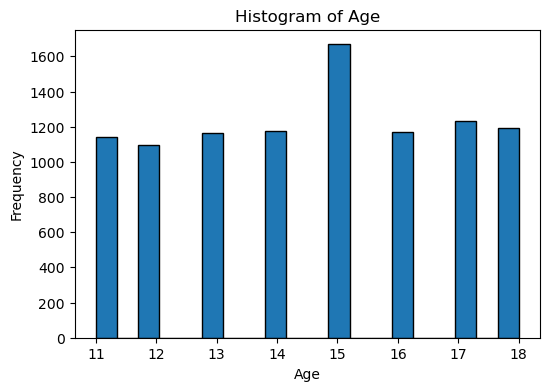

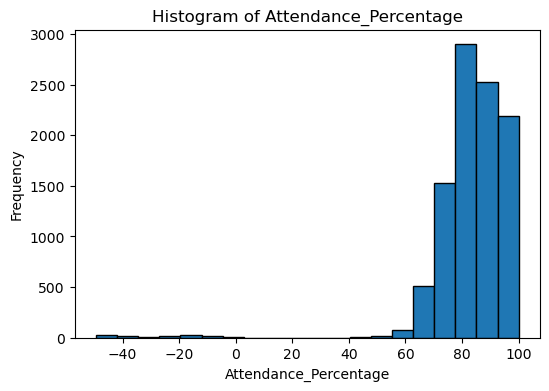

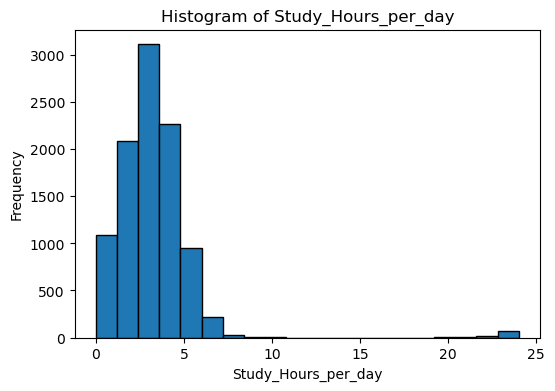

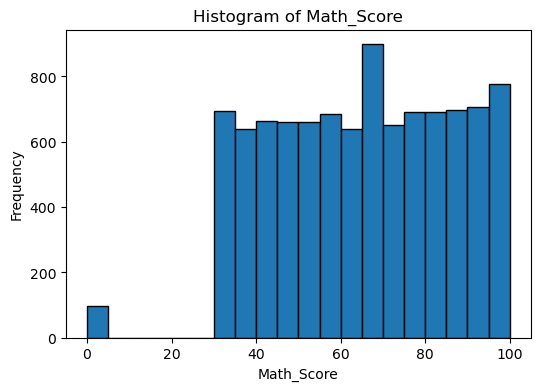

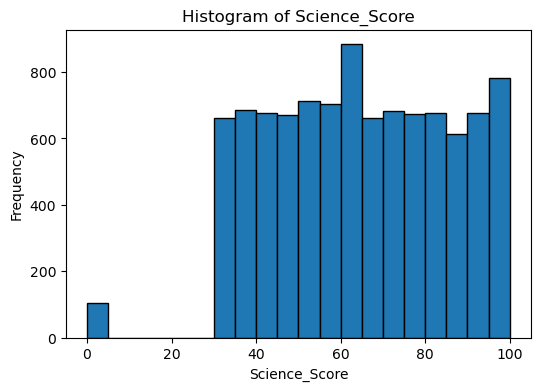

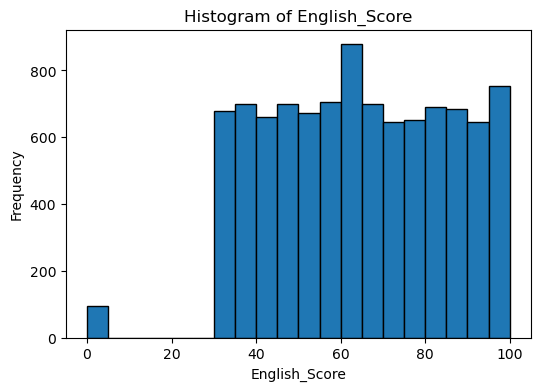

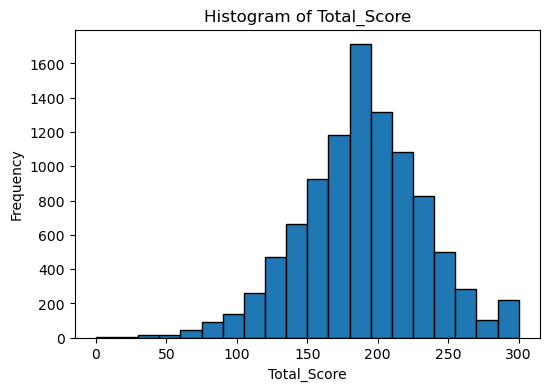

In [683]:
import matplotlib.pyplot as plt

num_cols = [
    "Age",
    "Attendance_Percentage",
    "Study_Hours_per_day",
    "Math_Score",
    "Science_Score",
    "English_Score",
    "Total_Score"
]

for col in num_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=20, edgecolor='black')
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

## Boxplot

Boxplot দিয়ে Outlier আছে কিনা দেখা যায়।

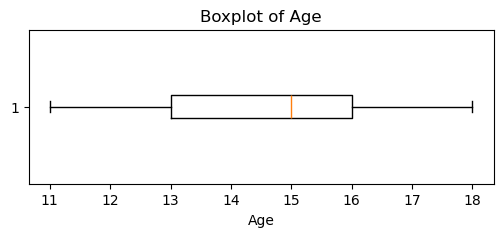

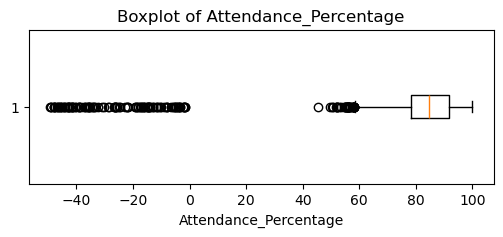

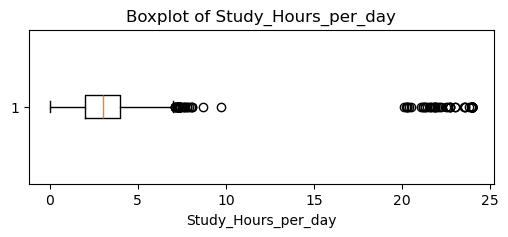

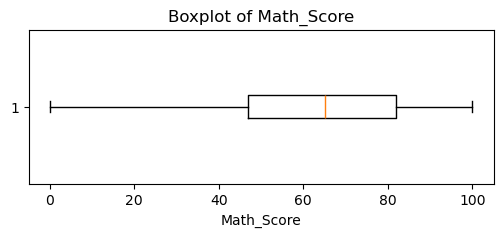

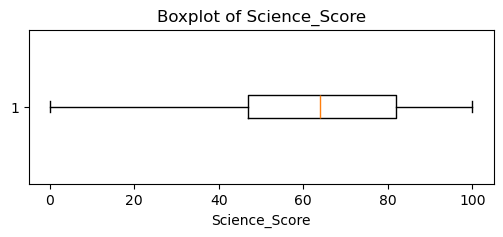

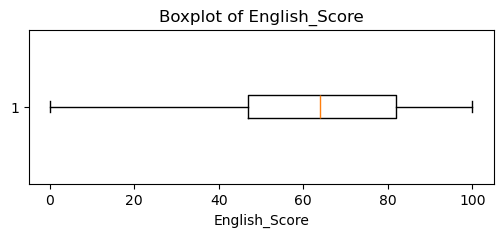

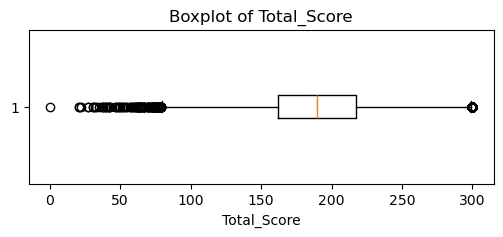

In [684]:
for col in num_cols:
    plt.figure(figsize=(6,2))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

## Categorical Feature-এর Distribution
Here we use Bar chat not Histogram

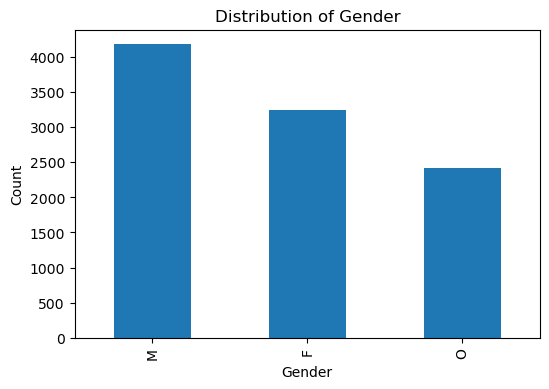

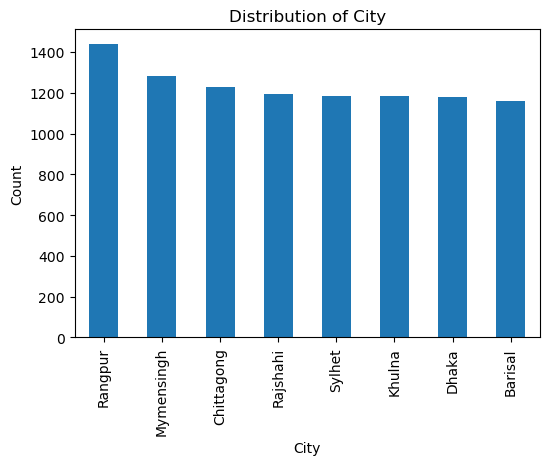

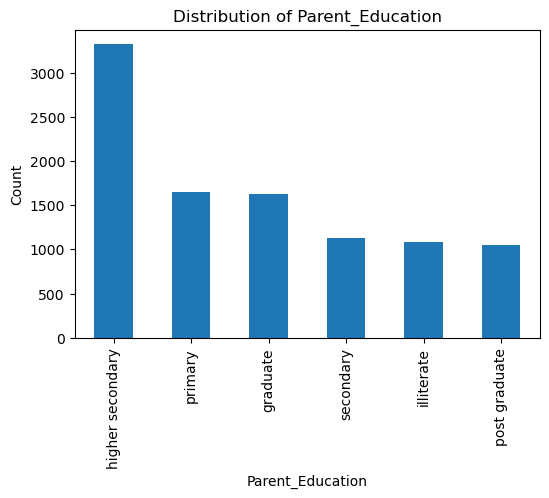

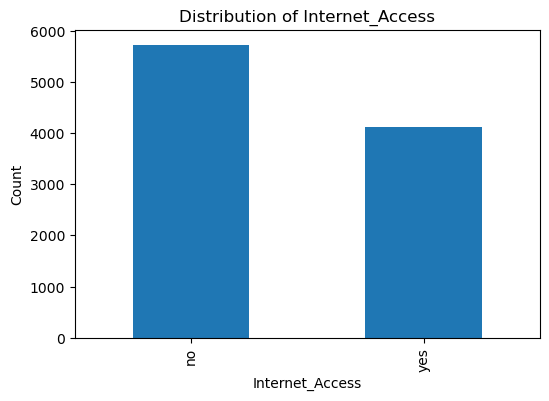

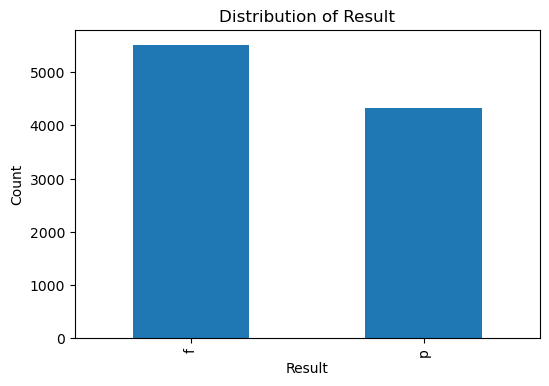

In [685]:
cat_cols = [
    "Gender",
    "City",
    "Parent_Education",
    "Internet_Access",
    "Result"
]

for col in cat_cols:
    plt.figure(figsize=(6,4))
    df[col].value_counts().plot(kind="bar")
    plt.title(f"Distribution of {col}")
    plt.ylabel("Count")
    plt.show()

## 1.Bivariate Analysis

In [686]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9850 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             9850 non-null   object 
 1   Name                   9850 non-null   object 
 2   Age                    9850 non-null   float64
 3   Gender                 9850 non-null   object 
 4   City                   9850 non-null   object 
 5   Class                  9850 non-null   int64  
 6   Attendance_Percentage  9850 non-null   float64
 7   Study_Hours_per_day    9850 non-null   float64
 8   Math_Score             9850 non-null   float64
 9   Science_Score          9850 non-null   float64
 10  English_Score          9850 non-null   float64
 11  Total_Score            9850 non-null   float64
 12  Parent_Education       9850 non-null   object 
 13  Internet_Access        9850 non-null   object 
 14  Result                 9850 non-null   object 
dtypes: float6

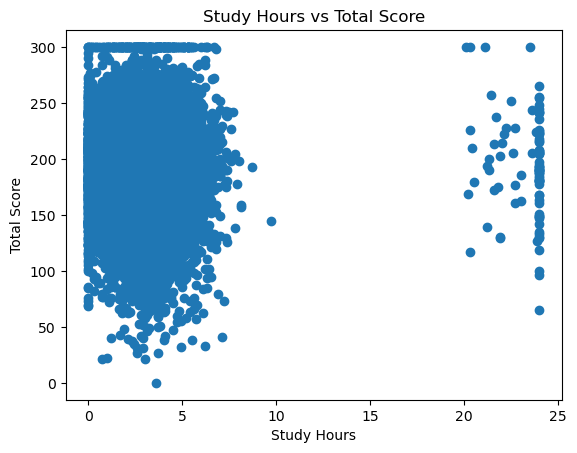

In [687]:
# Study Hours vs Total Score
plt.scatter(df["Study_Hours_per_day"], df["Total_Score"])
plt.xlabel("Study Hours")
plt.ylabel("Total Score")
plt.title("Study Hours vs Total Score")
plt.show()

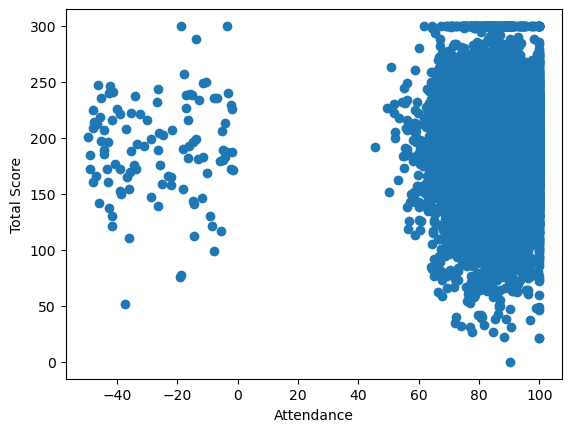

In [688]:
# Attendance vs Total Score
plt.scatter(df["Attendance_Percentage"], df["Total_Score"])
plt.xlabel("Attendance")
plt.ylabel("Total Score")
plt.show()

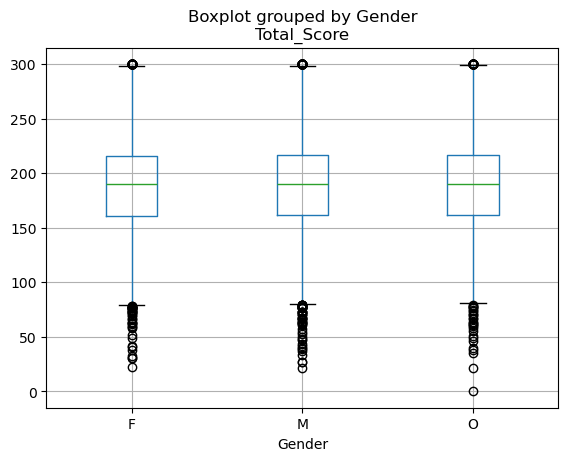

In [689]:
# Gender vs Total Score
# one categorial ,one numeric then we use boxplot
import matplotlib.pyplot as plt

df.boxplot(column="Total_Score", by="Gender")
plt.show()

## 2.Correlation
only used for numerical column

In [690]:

import matplotlib.pyplot as plt
import seaborn as sns

corr = df.corr(numeric_only=True)
corr


,Age,Class,Attendance_Percentage,Study_Hours_per_day,Math_Score,Science_Score,English_Score,Total_Score
Age,1.000000,-0.016022,-0.004774,-0.011433,0.005987,-0.009042,0.018998,0.002399
Class,-0.016022,1.000000,0.016040,-0.011214,0.002661,-0.003734,0.007768,-0.001175
Attendance_Percentage,-0.004774,0.016040,1.000000,-0.005390,-0.009120,0.007620,0.011718,0.007462
Study_Hours_per_day,-0.011433,-0.011214,-0.005390,1.000000,-0.001695,0.011192,-0.004129,0.003676
Math_Score,0.005987,0.002661,-0.009120,-0.001695,1.000000,-0.013738,0.005989,0.497042
Science_Score,-0.009042,-0.003734,0.007620,0.011192,-0.013738,1.000000,0.011033,0.497372
English_Score,0.018998,0.007768,0.011718,-0.004129,0.005989,0.011033,1.000000,0.504589
Total_Score,0.002399,-0.001175,0.007462,0.003676,0.497042,0.497372,0.504589,1.000000


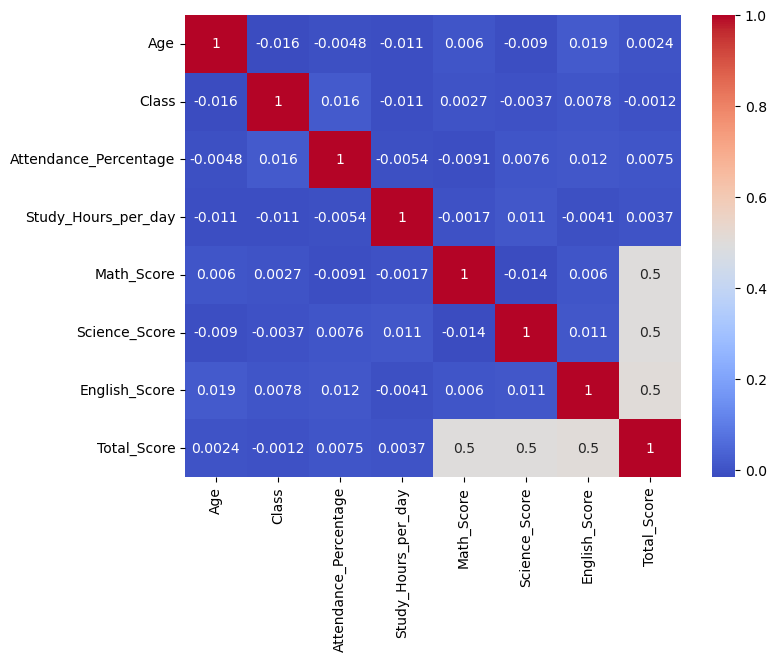

In [691]:

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)


plt.show()

## 3.Target-এর সাথে Correlation

In [692]:
# If Target was numeric

In [693]:
corr["Total_Score"].sort_values(ascending=False)

Total_Score              1.000000
English_Score            0.504589
Science_Score            0.497372
Math_Score               0.497042
Attendance_Percentage    0.007462
Study_Hours_per_day      0.003676
Age                      0.002399
Class                   -0.001175
Name: Total_Score, dtype: float64

## 4. Multivariate Analysis
একসাথে ৩ বা তার বেশি feature দেখা।

In [694]:
#Exmaple: Study Hours, Attendance, Total Score

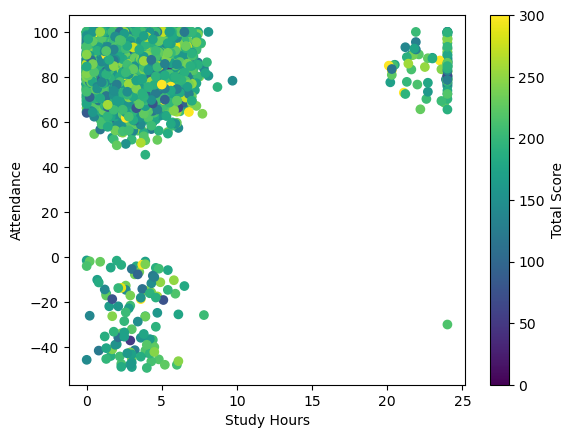

In [695]:
plt.scatter(
    df["Study_Hours_per_day"],
    df["Attendance_Percentage"],
    c=df["Total_Score"]
)

plt.xlabel("Study Hours")
plt.ylabel("Attendance")
plt.colorbar(label="Total Score")
plt.show()

## 3. Feature Engineering

In [696]:
df['Average_Score'] = (
    df['Math_Score'] +
    df['Science_Score'] +
    df['English_Score']
)/3

In [697]:
df.head(10)

,Student_ID,Name,Age,Gender,City,Class,Attendance_Percentage,Study_Hours_per_day,Math_Score,Science_Score,English_Score,Total_Score,Parent_Education,Internet_Access,Result,Average_Score
0,1978,Bristi Khan,16.0,M,Mymensingh,8,77.0,2.6,83.0,62.0,68.0,213.0,primary,no,f,71.000000
1,3881,hasan akter,12.0,F,Dhaka,10,88.5,3.8,45.0,56.0,92.0,193.0,secondary,no,f,64.333333
2,53,Sohan Talukder,14.0,M,Khulna,7,65.1,3.6,37.0,82.0,89.0,208.0,higher secondary,no,f,69.333333
3,2552,Mitu Hossain,11.0,F,Rajshahi,10,82.8,4.2,83.0,96.0,59.0,238.0,illiterate,no,p,79.333333
4,2247,Ayesha Ahmed,14.0,O,Khulna,9,94.2,1.4,81.0,36.0,48.0,165.0,primary,no,p,55.000000
5,271,Jannat Hossain,18.0,M,Sylhet,10,82.1,4.9,47.0,48.0,65.0,160.0,graduate,no,p,53.333333
6,602,Imran Ahmed,17.0,F,Barisal,9,96.1,4.6,83.0,51.0,94.0,228.0,illiterate,no,p,76.000000
7,2442,Rakib Chowdhury,12.0,F,Mymensingh,10,100.0,3.5,36.0,80.0,46.0,162.0,primary,no,p,54.000000
8,3287,Nadia Islam,15.0,F,Rangpur,10,83.6,5.7,76.0,75.0,64.0,151.0,higher secondary,yes,p,71.666667
9,2968,Momo Ahmed,18.0,F,Dhaka,8,77.9,1.7,65.0,92.0,30.0,122.0,higher secondary,no,p,62.333333


In [698]:

df['Study_Efficiency'] = (
    df['Average_Score'] /
    (df['Study_Hours_per_day']+1)
)

In [699]:
df['Attendance_Category'] = pd.cut(
    df['Attendance_Percentage'],
    bins=[0,75,90,100],
    labels=['Low','Medium','High']
)

In [700]:
df['Attendance_Category']

0       Medium
1       Medium
2          Low
3       Medium
4         High
         ...  
9995    Medium
9996      High
9997    Medium
9998      High
9999    Medium
Name: Attendance_Category, Length: 9850, dtype: category
Categories (3, object): ['Low' < 'Medium' < 'High']

In [701]:
df=pd.get_dummies(df,columns=['Gender',],drop_first=True,dtype=int)

In [702]:
from sklearn.preprocessing import LabelEncoder

In [703]:
le = LabelEncoder()
df['Internet_Access']=le.fit_transform(df['Internet_Access'])

In [704]:
from sklearn.preprocessing import OrdinalEncoder
ord_enc=OrdinalEncoder(categories=[['illiterate',
    'primary',
    'secondary',
    'higher secondary',
    'graduate',
    'post graduate']])

df['Parent_Education']=ord_enc.fit_transform(df[['Parent_Education']])

In [705]:
import category_encoders as ce

target_enc = ce.TargetEncoder(cols=['City', 'Class'])

df[['City', 'Class']] = target_enc.fit_transform(
    df[['City', 'Class']],
    df['Result']   
)

In [706]:
print(df["Attendance_Category"].unique())

['Medium', 'Low', 'High', NaN]
Categories (3, object): ['Low' < 'Medium' < 'High']


In [707]:
df["Attendance_Category"] = df["Attendance_Category"].fillna(
    df["Attendance_Category"].mode()[0]
)

In [708]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(
    categories=[['Low', 'Medium', 'High']]
)

df[['Attendance_Category']] = oe.fit_transform(
    df[['Attendance_Category']]
)

In [709]:
df['Result']=le.fit_transform(df['Result'])

In [710]:
df.head(10)

,Student_ID,Name,Age,City,Class,Attendance_Percentage,Study_Hours_per_day,Math_Score,Science_Score,English_Score,Total_Score,Parent_Education,Internet_Access,Result,Average_Score,Study_Efficiency,Attendance_Category,Gender_M,Gender_O
0,1978,Bristi Khan,16.0,0.450000,0.436677,77.0,2.6,83.0,62.0,68.0,213.0,1.0,0,0,71.000000,19.722222,1.0,1,0
1,3881,hasan akter,12.0,0.424448,0.433747,88.5,3.8,45.0,56.0,92.0,193.0,2.0,0,0,64.333333,13.402778,1.0,0,0
2,53,Sohan Talukder,14.0,0.421097,0.435318,65.1,3.6,37.0,82.0,89.0,208.0,3.0,0,0,69.333333,15.072464,0.0,1,0
3,2552,Mitu Hossain,11.0,0.460251,0.433747,82.8,4.2,83.0,96.0,59.0,238.0,0.0,0,1,79.333333,15.256410,1.0,0,0
4,2247,Ayesha Ahmed,14.0,0.421097,0.446050,94.2,1.4,81.0,36.0,48.0,165.0,1.0,0,1,55.000000,22.916667,2.0,0,1
5,271,Jannat Hossain,18.0,0.442664,0.433747,82.1,4.9,47.0,48.0,65.0,160.0,4.0,0,1,53.333333,9.039548,1.0,1,0
6,602,Imran Ahmed,17.0,0.447028,0.446050,96.1,4.6,83.0,51.0,94.0,228.0,0.0,0,1,76.000000,13.571429,2.0,0,0
7,2442,Rakib Chowdhury,12.0,0.450000,0.433747,100.0,3.5,36.0,80.0,46.0,162.0,1.0,0,1,54.000000,12.000000,2.0,0,0
8,3287,Nadia Islam,15.0,0.438499,0.433747,83.6,5.7,76.0,75.0,64.0,151.0,3.0,1,1,71.666667,10.696517,1.0,0,0
9,2968,Momo Ahmed,18.0,0.424448,0.436677,77.9,1.7,65.0,92.0,30.0,122.0,3.0,0,1,62.333333,23.086420,1.0,0,0


## 4.Train-Test Split : 5. Model Train ও Fit: 6.Logistic ও Linear Regression প্রয়োগ করো : 7. Predict: 8. Model Evaluation

In [711]:
from sklearn.model_selection import train_test_split

In [712]:
X = df.drop(columns=[
    'Student_ID',
    'Name',
    'Result',
    'Total_Score',
    'Math_Score',
    'Science_Score',
    'English_Score',
    'Average_Score',
    'Study_Efficiency'
])

y = df['Total_Score']

In [713]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [714]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [715]:
X_train_scaled = scaler.fit_transform(X_train)

In [716]:
X_test_scaled = scaler.transform(X_test)

In [717]:
from sklearn.linear_model import LinearRegression
lin_model = LinearRegression()
lin_model.fit(X_train_scaled, y_train)
y_pred = lin_model.predict(X_test_scaled)

In [718]:
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)
print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
mse = mean_squared_error(y_test, y_pred)
print(f"MSE (Mean Squared Error): {mse:.3f}")

R2: -0.004514033651322524
MAE: 34.064608966298486
RMSE: 44.63879371167217
MSE (Mean Squared Error): 1992.622


In [719]:
# Linear Regression
print("Train R²:", lin_model.score(X_train, y_train))
print("Test R² :", lin_model.score(X_test, y_test))

Train R²: -0.06417947315966832
Test R² : -0.05499514507246439


C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [720]:
# (b) Overfitting / Underfitting Analysis

# ---------------------- Linear Regression ----------------------

# Train R² = -0.0642
# Test R²  = -0.0550

# The training and testing R² scores are both negative.
# A negative R² means the model performs worse than simply
# predicting the mean of the target variable.

# The train and test R² values are very close to each other.
# This means there is no significant gap between training
# and testing performance.

# Therefore, the model is NOT overfitting.

# However, since both R² scores are negative,
# the model failed to learn the relationship
# between the features and the target.

# Conclusion:
# - No Overfitting
# - Model is Underfitting
# - Better feature engineering, feature selection,
#   or a more powerful regression model may improve performance.

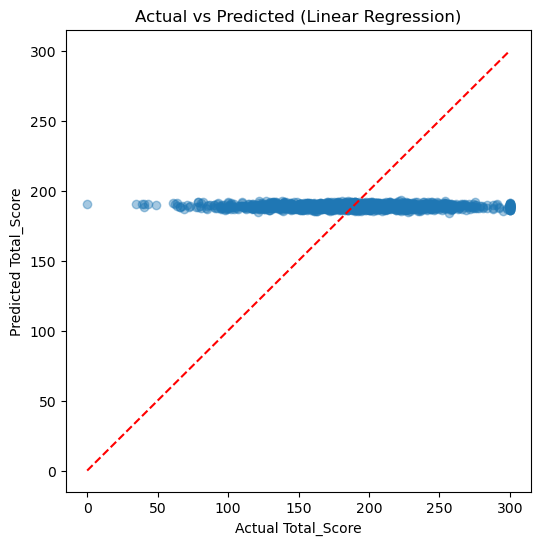

In [721]:
# Actual vs Predicted plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Total_Score')
plt.ylabel('Predicted Total_Score')
plt.title('Actual vs Predicted (Linear Regression)')
plt.show()

In [722]:
# Coefficient interpretation
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lin_model.coef_})
coef_df.sort_values('Coefficient', ascending=False)

,Feature,Coefficient
9,Gender_O,1.061397
8,Gender_M,0.620753
6,Internet_Access,0.408063
0,Age,0.364668
7,Attendance_Category,0.197030
1,City,0.176758
3,Attendance_Percentage,0.091034
2,Class,-0.061946
4,Study_Hours_per_day,-0.253649
5,Parent_Education,-0.799344


In [723]:
drop_for_log = ['Student_ID', 'Name', 'Result']

X_log = df.drop(columns=drop_for_log, errors='ignore')
y_log = df['Result']

In [724]:
X_train, X_test, y_train, y_test = train_test_split(
    X_log, y_log,
    test_size=0.2,
    random_state=42,
    stratify=y_log
)

In [725]:
scaler2 = StandardScaler()
X_train_scaled = scaler2.fit_transform(X_train)
X_test_scaled = scaler2.transform(X_test)

In [726]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(solver='liblinear',
    max_iter=5000,
    random_state=42
    )

In [727]:
log_model.fit(X_train_scaled, y_train)
y_pred = log_model.predict(X_test_scaled)

In [728]:
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

In [729]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.5558375634517766
Precision: 0.3333333333333333
Recall: 0.011560693641618497
F1 Score: 0.0223463687150838
ROC-AUC: 0.5025553840922763


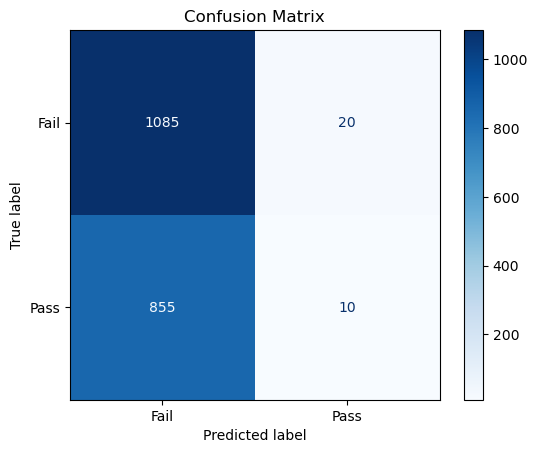

In [730]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Fail','Pass']).plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

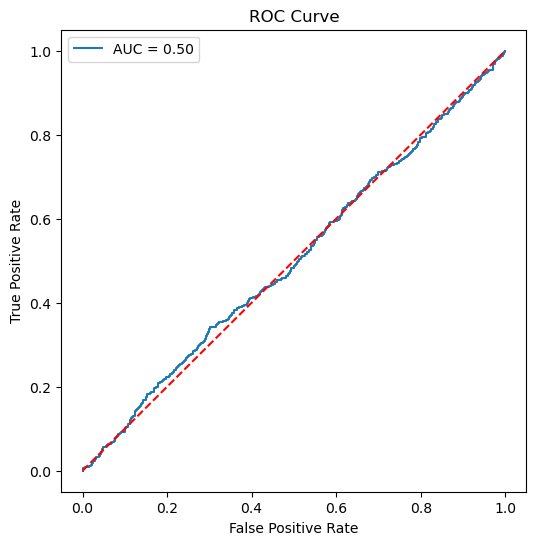

In [731]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_prob):.2f}')
plt.plot([0,1], [0,1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## Task 9

In [732]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Metric": [
        "R² Score",
        "MAE",
        "RMSE",
        "MSE",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Linear Regression": [
        -0.0045,
        34.0646,
        44.6388,
        1992.622,
        None,
        None,
        None,
        None,
        None
    ],
    "Logistic Regression": [
        None,
        None,
        None,
        None,
        0.5558,
        0.3333,
        0.0116,
        0.0223,
        0.5026
    ]
})

print(comparison_df)

      Metric  Linear Regression  Logistic Regression
0   R² Score            -0.0045                  NaN
1        MAE            34.0646                  NaN
2       RMSE            44.6388                  NaN
3        MSE          1992.6220                  NaN
4   Accuracy                NaN               0.5558
5  Precision                NaN               0.3333
6     Recall                NaN               0.0116
7   F1 Score                NaN               0.0223
8    ROC-AUC                NaN               0.5026


## Task 10

In [733]:
# (a) Which Model Performed Better?

# ---------------------- Linear Regression ----------------------

# R² Score = -0.0045
# A negative R² score means the model performs even worse than simply
# predicting the mean of the target variable.
# This indicates that the model failed to learn the relationship
# between the input features and the target.
print("R² Score = -0.0045")

# MAE = 34.0646
# Mean Absolute Error (MAE) means the model's prediction is off by
# about 34 units on average.
# A lower MAE is always better, so this error is relatively high.
print("MAE = 34.0646")

# RMSE = 44.6388
# RMSE also measures prediction error but gives more penalty
# to large errors (outliers).
# Since RMSE is much larger than MAE, the model likely made
# several large prediction mistakes.
print("RMSE = 44.6388")

# Conclusion:
# Linear Regression performs poorly because:
# - Negative R² score
# - High MAE
# - High RMSE
# Therefore, it is not suitable for this dataset.


# ---------------------- Logistic Regression ----------------------

# Accuracy = 0.5558
# Accuracy means the model correctly classified about 55.58%
# of all test samples.
# This is only slightly better than random guessing.
print("Accuracy = 0.5558")

# Precision = 0.3333
# Precision tells us among all samples predicted as Positive,
# only 33.33% were actually Positive.
# The model produces many false positive predictions.
print("Precision = 0.3333")

# Recall = 0.0116
# Recall measures how many actual Positive samples
# were correctly identified.
# A recall of only 1.16% is extremely poor,
# meaning the model missed almost all positive cases.
print("Recall = 0.0116")

# F1 Score = 0.0223
# F1 Score is the harmonic mean of Precision and Recall.
# It balances both False Positives and False Negatives.
# A score of 0.0223 is extremely low, showing
# very poor classification performance.
print("F1 Score = 0.0223")

# ROC-AUC = 0.5038
# ROC-AUC measures how well the model separates
# Positive and Negative classes.
# A value of 0.5 means random guessing.
# Since 0.5038 is very close to 0.5,
# the model has almost no discriminative ability.
print("ROC-AUC = 0.5038")

# Conclusion:
# Logistic Regression achieved about 55% accuracy,
# but Recall, F1 Score, and ROC-AUC are extremely low.
# Therefore, the model fails to identify the Positive class effectively.


# ---------------------- Overall Comparison ----------------------

# Both models performed poorly on this dataset.
#
# Linear Regression:
# - Negative R² Score
# - High MAE and RMSE
# - Failed to learn the relationship between features and target.
#
# Logistic Regression:
# - Moderate Accuracy
# - Very low Precision, Recall, and F1 Score
# - ROC-AUC is almost equal to random guessing.
#
# Final Conclusion:
# Neither model performed well.


R² Score = -0.0045
MAE = 34.0646
RMSE = 44.6388
Accuracy = 0.5558
Precision = 0.3333
Recall = 0.0116
F1 Score = 0.0223
ROC-AUC = 0.5038


In [734]:
# (b) Overfitting / Underfitting Analysis
#  1.Logistic Regression

print("Train Accuracy:", log_model.score(X_train, y_train))
print("Test Accuracy :", log_model.score(X_test, y_test))

Train Accuracy: 0.5606598984771574
Test Accuracy : 0.5609137055837563


C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [735]:
# (b) Overfitting / Underfitting Analysis

# Logistic Regression

# Train Accuracy = 0.5607 (56.07%)
# Test Accuracy  = 0.5609 (56.09%)

# The training and testing accuracies are almost identical.
# The difference is only about 0.03%.

# Since the training accuracy is not much higher than the testing accuracy,
# the model is NOT overfitting.

# However, both accuracies are quite low (around 56%).
# This indicates that the model is not learning enough patterns
# from the data.

# Therefore, the Logistic Regression model is UNDERFITTING.

# Conclusion:
# - No Overfitting
# - Model is Underfitting
# - Better feature engineering, handling class imbalance,
#   or using a more powerful model may improve performance.

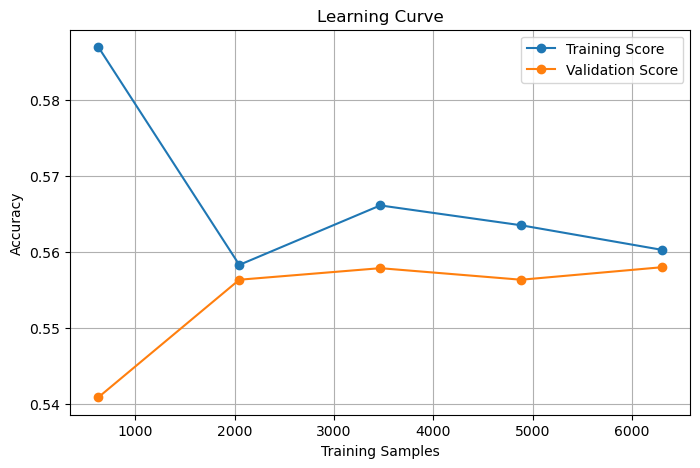

In [736]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    log_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, marker='o', label='Training Score')
plt.plot(train_sizes, test_mean, marker='o', label='Validation Score')

plt.xlabel("Training Samples")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.grid(True)

plt.show()

In [737]:
# Learning Curve is used to evaluate how a machine learning model
# performs as the size of the training data increases.

# It compares the Training Score and Validation Score.

# It helps us to:
# 1. Detect Overfitting.
# 2. Detect Underfitting.
# 3. Check whether adding more training data can improve performance.
# 4. Evaluate the model's generalization ability.

In [738]:
# ---------------------- Conclusion ----------------------

# Both Linear Regression and Logistic Regression performed poorly
# on this dataset.

# Logistic Regression is the better choice because this is a
# classification problem, while Linear Regression is designed
# for predicting continuous values.

# However, the low Accuracy (55.58%), Recall, F1 Score, and ROC-AUC
# indicate that the model needs improvement through better feature
# engineering, handling class imbalance, and hyperparameter tuning.

# In real-world applications, Logistic Regression can be used for
# binary classification tasks such as customer churn prediction,
# disease diagnosis, spam email detection, and fraud detection.